In [1]:
import pandas as pd

In [2]:
data = pd.read_parquet('data.parquet')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   economy                   17490 non-null  str    
 1   time                      17490 non-null  int64  
 2   PIB per capita            14745 non-null  float64
 3   var IPC                   11472 non-null  float64
 4   TD total                  6096 non-null   float64
 5   TD juvenil                4298 non-null   float64
 6   TD masculina              5480 non-null   float64
 7   TD femenina               5467 non-null   float64
 8   TGP                       5733 non-null   float64
 9   PEA                       8410 non-null   float64
 10  Crecimiento del PIB       14323 non-null  float64
 11  Rentas del carbon % PIB   10662 non-null  float64
 12  Empleo vulnerable         8176 non-null   float64
 13  Gasto P educacion         5739 non-null   float64
 14  GINI             

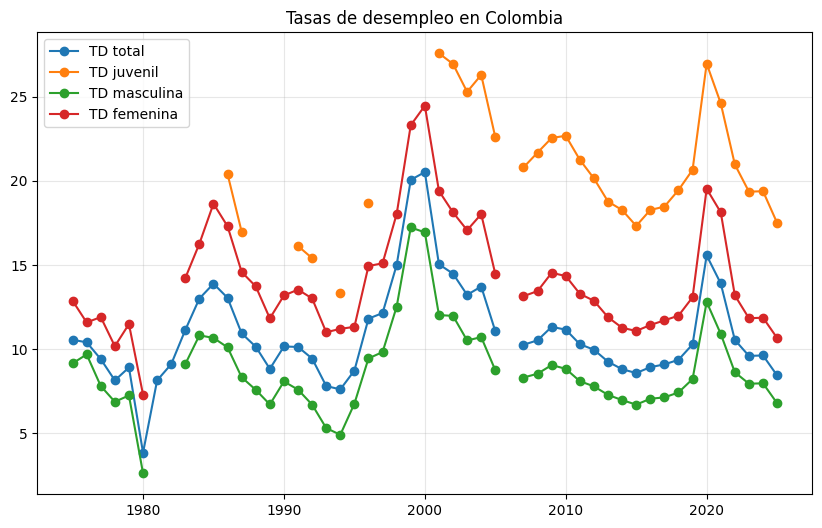

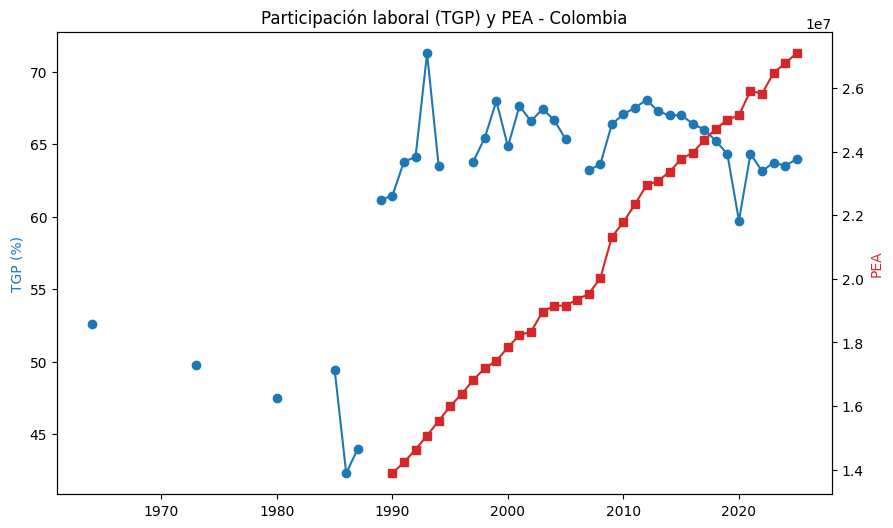

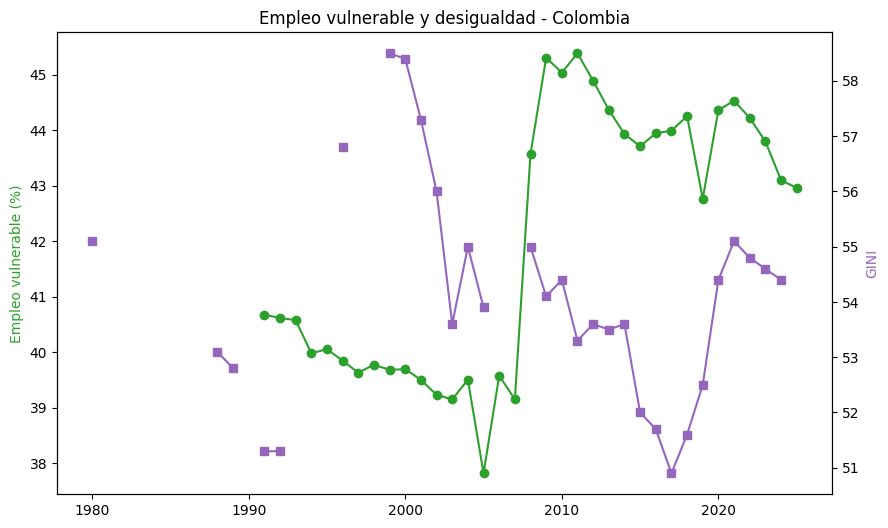

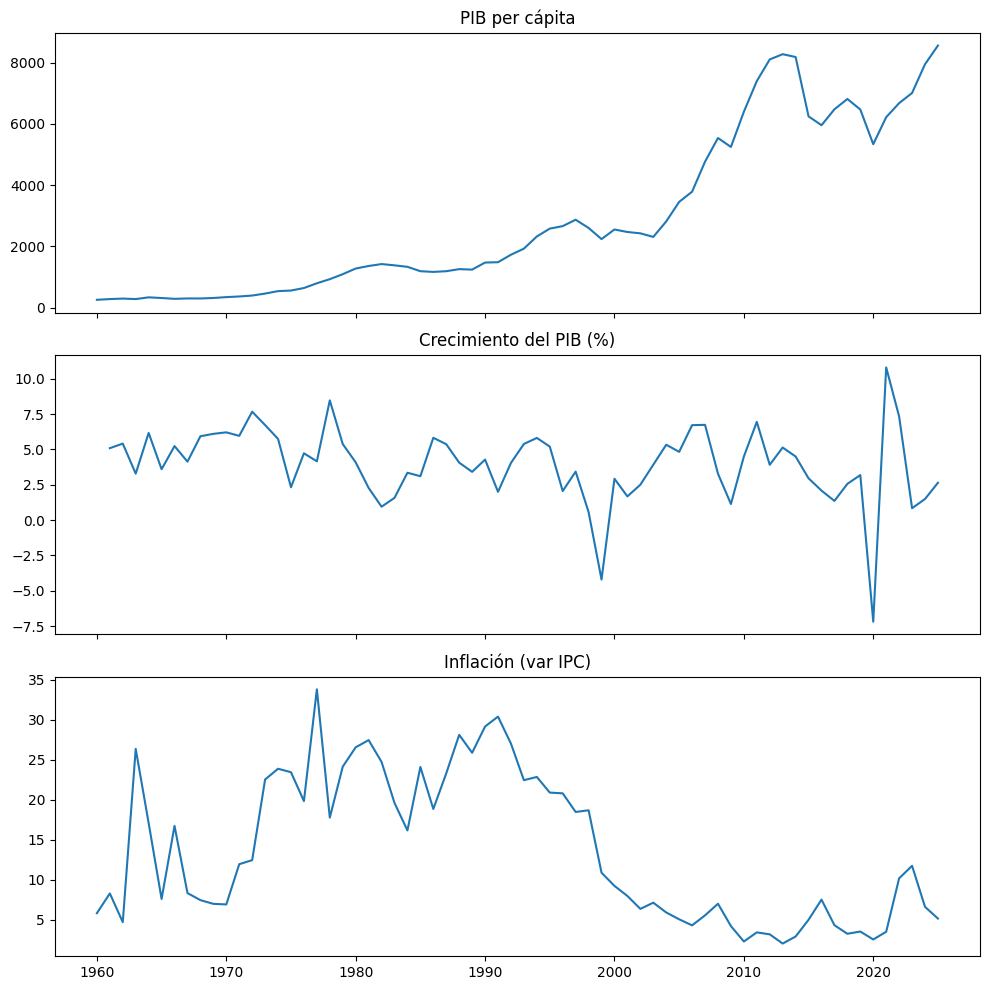

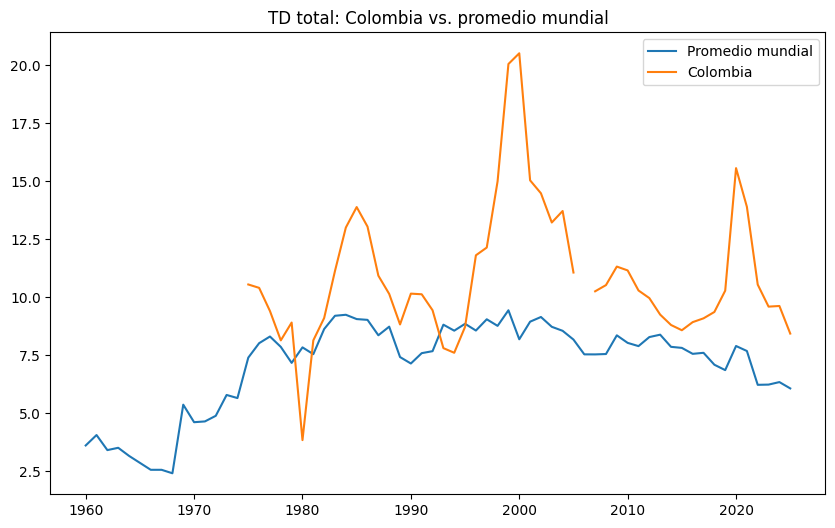

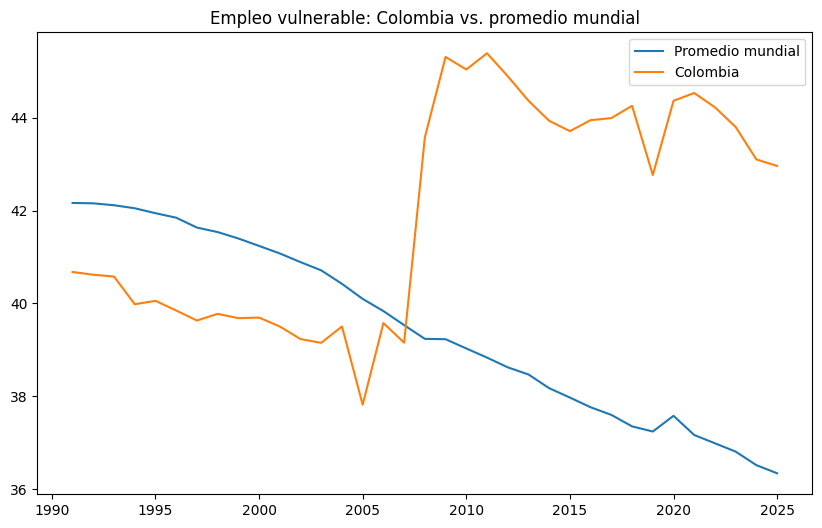

Año más reciente con datos: 2025
      economy  TD total
3761      DJI    38.782
12935     PSE    28.710
10361     MKD    11.531
4685      ESP    10.500
329       AGO    10.391
4949      FIN     9.700
2639      CHL     8.894
5873      GRC     8.838
14717     SWE     8.800
3035      COL     8.428
16103     TUR     8.400
12209     PAN     8.306
5081      FRA     7.700
8777      LCA     7.661
4751      EST     7.500
                     TD total   TGP  Empleo vulnerable  GINI  \
TD total                 1.00  0.08              -0.36  0.69   
TGP                      0.08  1.00              -0.05 -0.02   
Empleo vulnerable       -0.36 -0.05               1.00 -0.41   
GINI                     0.69 -0.02              -0.41  1.00   
Gasto P educacion        0.33 -0.69              -1.00 -1.00   
PIB per capita          -0.12  0.50               0.83 -0.26   
var IPC                 -0.26 -0.52              -0.48 -0.09   
Crecimiento del PIB     -0.36 -0.17              -0.02 -0.16   

      

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Preparación ---
col = data[data['economy'] == 'COL'].sort_values('time')
latest_year = data['time'].max()

# 1. Desempleo en Colombia (total, juvenil, por sexo)
fig, ax = plt.subplots(figsize=(10,6))
for c in ['TD total','TD juvenil','TD masculina','TD femenina']:
    ax.plot(col['time'], col[c], marker='o', label=c)
ax.set_title('Tasas de desempleo en Colombia')
ax.legend(); ax.grid(alpha=.3)
plt.savefig('col_desempleo.png', dpi=150, bbox_inches='tight'); plt.show()

# 2. TGP y PEA
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(col['time'], col['TGP'], color='tab:blue', marker='o', label='TGP')
ax1.set_ylabel('TGP (%)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(col['time'], col['PEA'], color='tab:red', marker='s', label='PEA')
ax2.set_ylabel('PEA', color='tab:red')
plt.title('Participación laboral (TGP) y PEA - Colombia')
plt.savefig('col_tgp_pea.png', dpi=150, bbox_inches='tight'); plt.show()

# 3. Empleo vulnerable y desigualdad (GINI)
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(col['time'], col['Empleo vulnerable'], color='tab:green', marker='o', label='Empleo vulnerable (%)')
ax1.set_ylabel('Empleo vulnerable (%)', color='tab:green')
ax2 = ax1.twinx()
ax2.plot(col['time'], col['GINI'], color='tab:purple', marker='s', label='GINI')
ax2.set_ylabel('GINI', color='tab:purple')
plt.title('Empleo vulnerable y desigualdad - Colombia')
plt.savefig('col_vulnerable_gini.png', dpi=150, bbox_inches='tight'); plt.show()

# 4. Contexto macro: PIB per cápita, crecimiento del PIB, inflación
fig, axes = plt.subplots(3,1, figsize=(10,10), sharex=True)
axes[0].plot(col['time'], col['PIB per capita']); axes[0].set_title('PIB per cápita')
axes[1].plot(col['time'], col['Crecimiento del PIB']); axes[1].set_title('Crecimiento del PIB (%)')
axes[2].plot(col['time'], col['var IPC']); axes[2].set_title('Inflación (var IPC)')
plt.tight_layout()
plt.savefig('col_macro.png', dpi=150, bbox_inches='tight'); plt.show()

# 5. Colombia vs. promedio mundial: desempleo
world_td = data.groupby('time')['TD total'].mean()
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(world_td.index, world_td.values, label='Promedio mundial')
ax.plot(col['time'], col['TD total'], label='Colombia')
ax.legend(); ax.set_title('TD total: Colombia vs. promedio mundial')
plt.savefig('global_vs_col_td.png', dpi=150, bbox_inches='tight'); plt.show()

# 6. Colombia vs. promedio mundial: empleo vulnerable
world_vuln = data.groupby('time')['Empleo vulnerable'].mean()
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(world_vuln.index, world_vuln.values, label='Promedio mundial')
ax.plot(col['time'], col['Empleo vulnerable'], label='Colombia')
ax.legend(); ax.set_title('Empleo vulnerable: Colombia vs. promedio mundial')
plt.savefig('global_vs_col_vuln.png', dpi=150, bbox_inches='tight'); plt.show()

# 7. Ranking de países por TD total en el año más reciente disponible
snapshot = (data[data['time'] == latest_year][['economy','TD total']]
            .dropna().sort_values('TD total', ascending=False))
print(f"Año más reciente con datos: {latest_year}")
print(snapshot.head(15))

# 8. Correlaciones entre variables laborales y macro (Colombia)
corr_vars = ['TD total','TGP','Empleo vulnerable','GINI','Gasto P educacion',
             'PIB per capita','var IPC','Crecimiento del PIB']
corr = col[corr_vars].corr()
print(corr.round(2))

# 9. Estadísticas descriptivas de Colombia
print(col[corr_vars].describe().round(2))